# Traffic Sign Recognition - 01: EDA

Classify German traffic signs into their type. Dataset: **GTSRB** (German Traffic Sign Recognition Benchmark) via HuggingFace `tanganke/gtsrb`, 43 sign classes. A committed 64x64 sample sits under `data/sample/<class>/`.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', len(classes)); print(classes)
print('total images:', len(imgs))

classes: 43
['blue circle with white arrows indicating a traffic circle', 'blue circle with white forward arrow mandatory', 'blue circle with white forward or left turn arrow mandatory', 'blue circle with white forward or right turn arrow mandatory', 'blue circle with white keep left arrow mandatory', 'blue circle with white keep right arrow mandatory', 'blue circle with white left turn arrow mandatory', 'blue circle with white right turn arrow mandatory', 'empty red and white circle', 'end - de-restriction of 80 kph speed limit', 'red and white circle 100 kph speed limit', 'red and white circle 120 kph speed limit', 'red and white circle 20 kph speed limit', 'red and white circle 30 kph speed limit', 'red and white circle 50 kph speed limit', 'red and white circle 60 kph speed limit', 'red and white circle 70 kph speed limit', 'red and white circle 80 kph speed limit', 'red and white circle no truck entry', 'red and white circle red car and black car no passing', 'red and white circle

## 1. Class balance

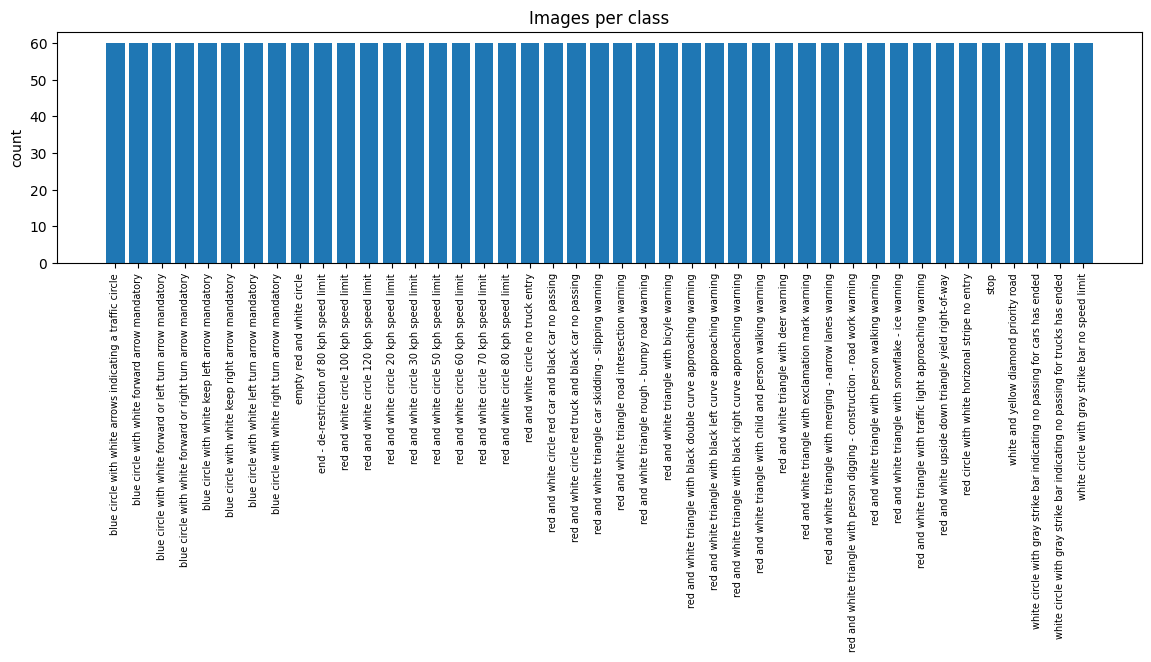

blue circle with white arrows indicating a traffic circle 60
blue circle with white forward arrow mandatory 60
blue circle with white forward or left turn arrow mandatory 60
blue circle with white forward or right turn arrow mandatory 60
blue circle with white keep left arrow mandatory 60
blue circle with white keep right arrow mandatory 60
blue circle with white left turn arrow mandatory 60
blue circle with white right turn arrow mandatory 60
empty red and white circle 60
end - de-restriction of 80 kph speed limit 60
red and white circle 100 kph speed limit 60
red and white circle 120 kph speed limit 60
red and white circle 20 kph speed limit 60
red and white circle 30 kph speed limit 60
red and white circle 50 kph speed limit 60
red and white circle 60 kph speed limit 60
red and white circle 70 kph speed limit 60
red and white circle 80 kph speed limit 60
red and white circle no truck entry 60
red and white circle red car and black car no passing 60
red and white circle red truck and

In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(min(14,1+len(classes)*0.5),3)); plt.bar(range(len(classes)), [cnt[c] for c in classes])
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=7); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-22s %d' % (k, cnt[k]))

## 2. One sample per class

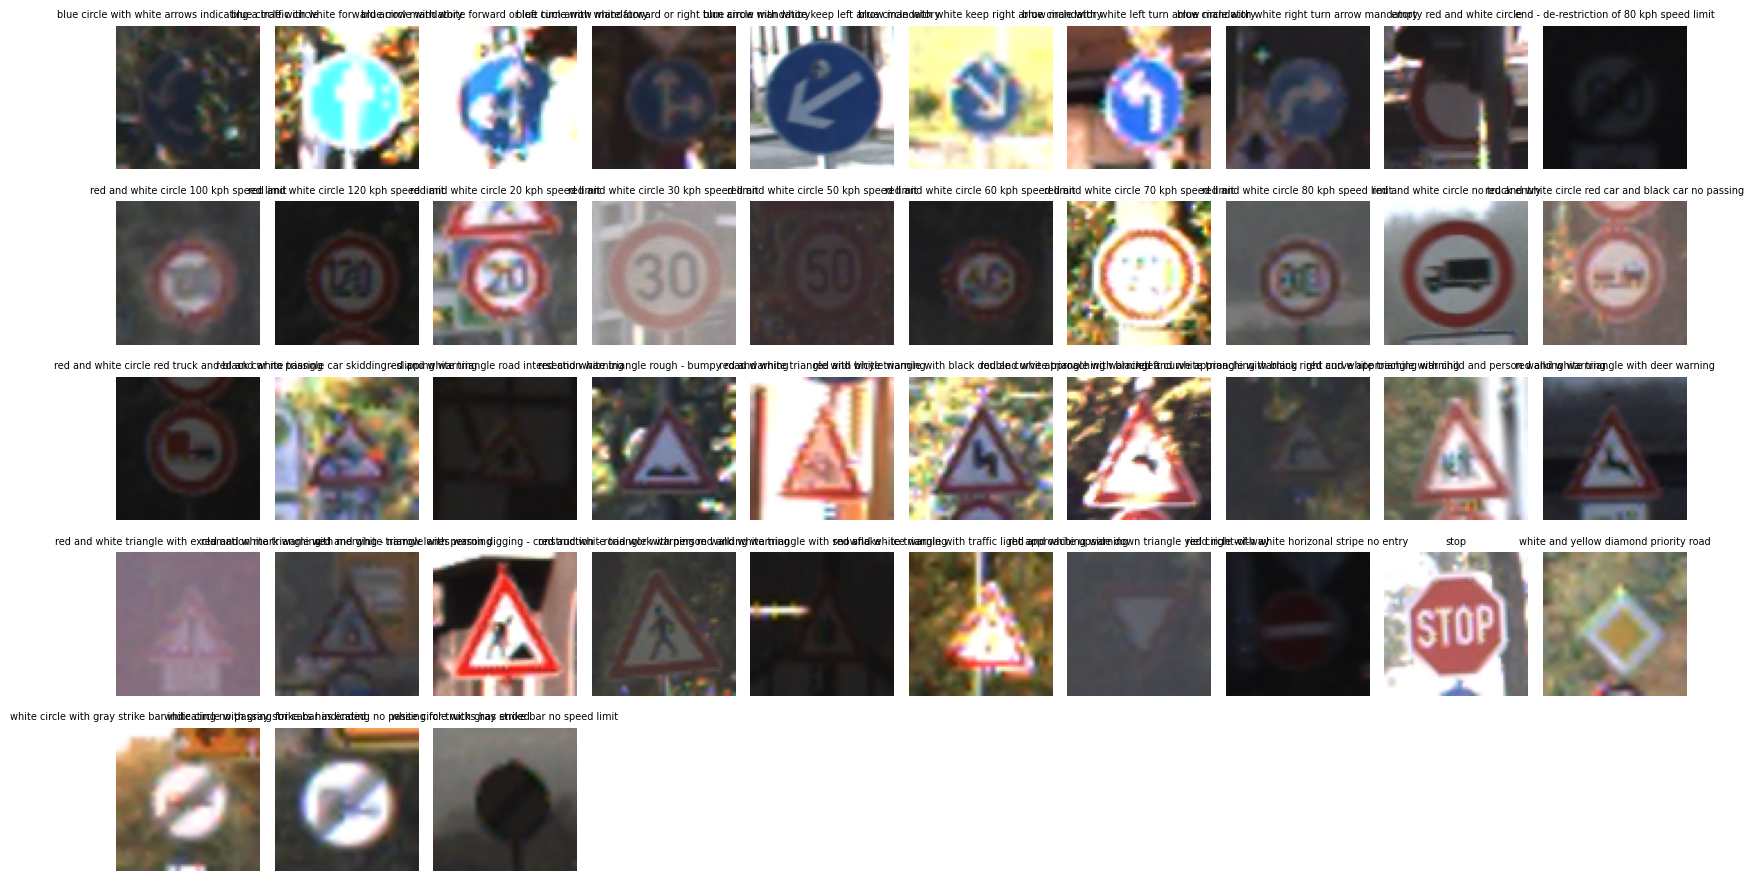

In [3]:
import math
n=len(classes); cols=min(n,10); rows=math.ceil(n/cols)
fig, ax = plt.subplots(rows, cols, figsize=(1.6*cols, 1.8*rows)); ax=np.atleast_2d(ax)
seen={}
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen[l]=im
for i,cl in enumerate(classes):
    a=ax[i//cols][i%cols]; a.imshow(seen[cl]); a.set_title(cl, fontsize=7); a.axis('off')
for j in range(n, rows*cols): ax[j//cols][j%cols].axis('off')
plt.tight_layout(); plt.show()

### Findings
43 sign classes, roughly balanced in the sample. Signs are small, cropped, and vary in lighting and angle, but each class has a distinct shape/colour/pictogram.